In [307]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [308]:
df = pd.read_csv('Loan Dataset.csv')

In [309]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [310]:
df['Gender'].value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

In [311]:
df['Married'].value_counts()

Married
Yes    398
No     213
Name: count, dtype: int64

In [312]:
df['Property_Area'].value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

In [313]:
# Dataset shape

df.shape

(614, 13)

In [314]:
# Data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [315]:
# null Values

df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [316]:
(df.isnull().sum())/len(df) *100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [317]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [318]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [319]:
# Duplicate values

df.duplicated().sum()

np.int64(0)

In [320]:
# Summary statistics

df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [321]:
df.describe( include = 'object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,614,614,614,614,614,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,502,401,360,480,532,233,422


In [322]:
# Separate numerical and categorical columns

numerical_cols = df.select_dtypes( include = ['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include = ['object']).columns

print( 'Numerical columns:', numerical_cols)
print( 'categorical columns:', categorical_cols)

Numerical columns: Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')
categorical columns: Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [323]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

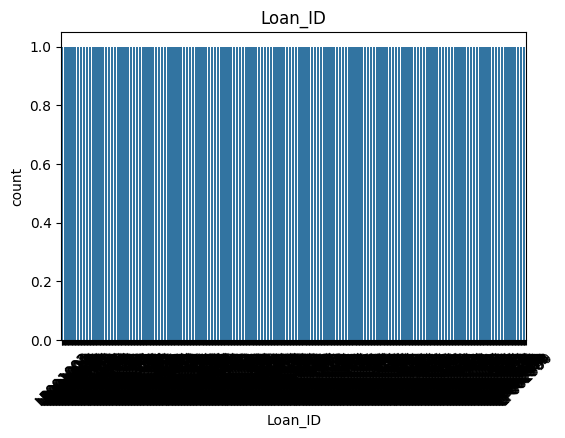

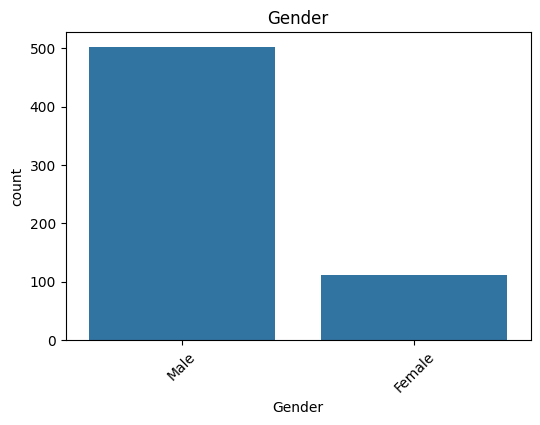

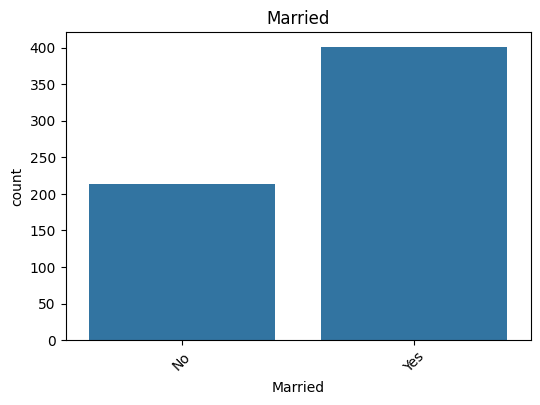

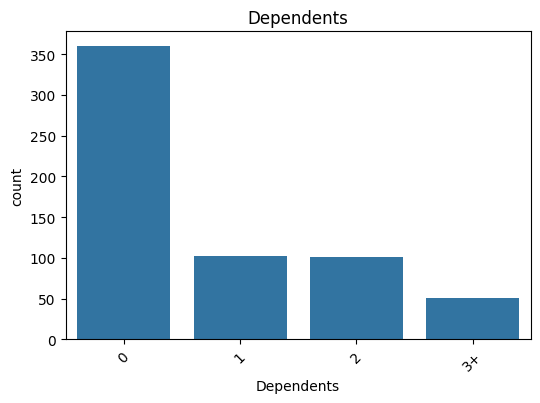

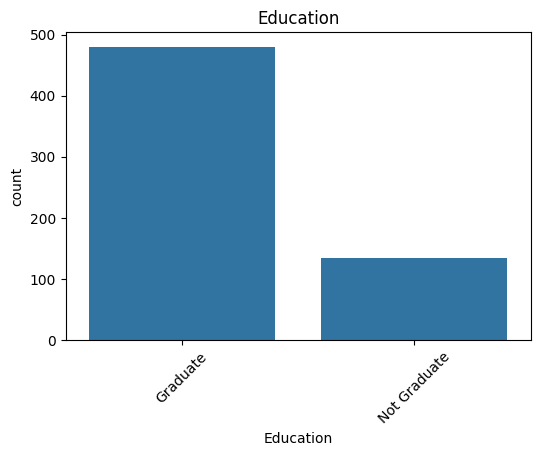

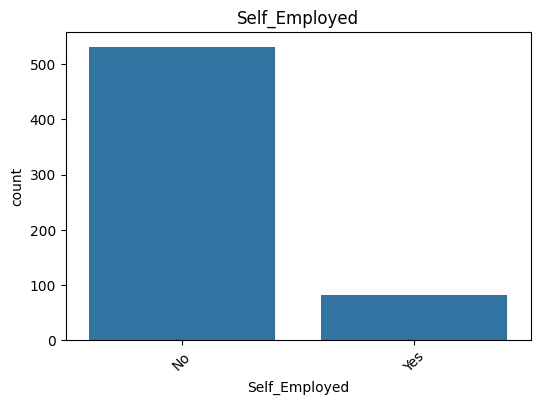

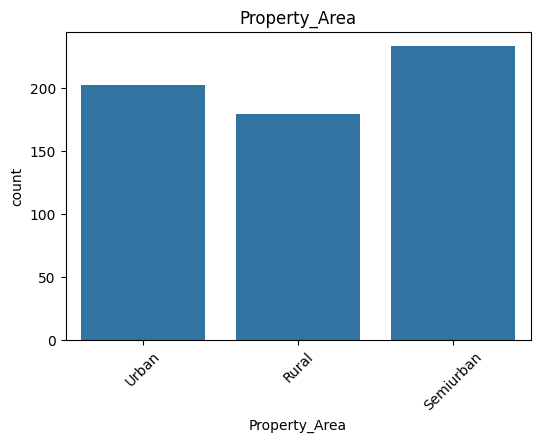

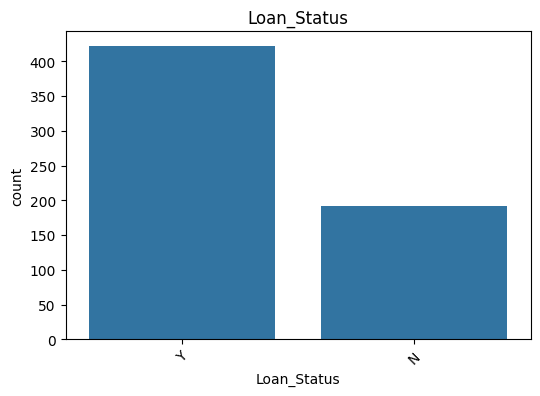

In [324]:
# Univariate analysis

import matplotlib.pyplot as plt
import seaborn as sns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()


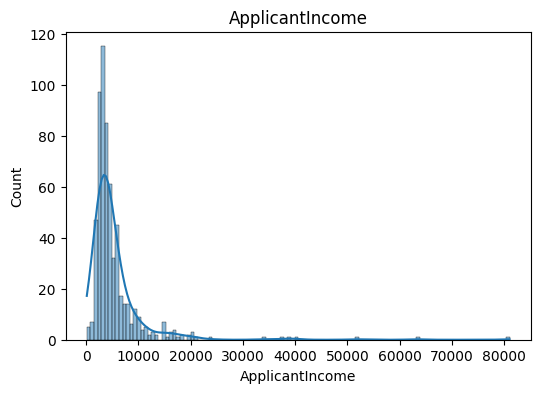

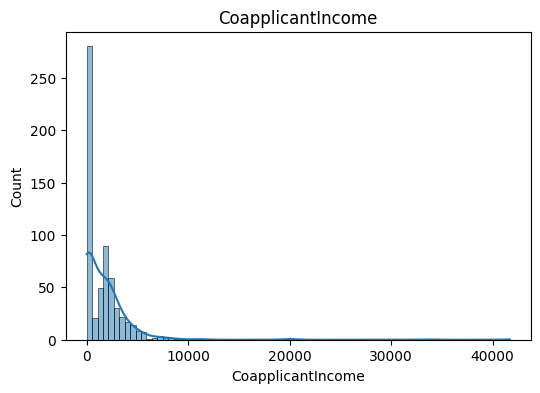

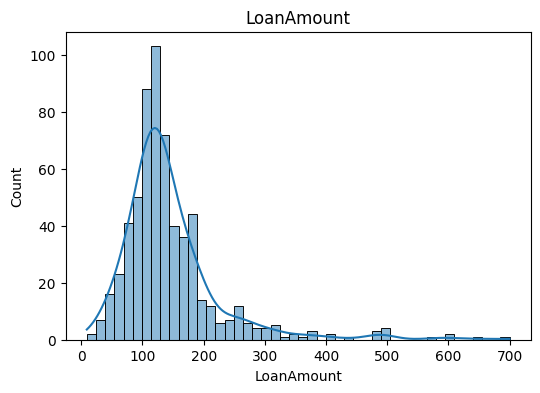

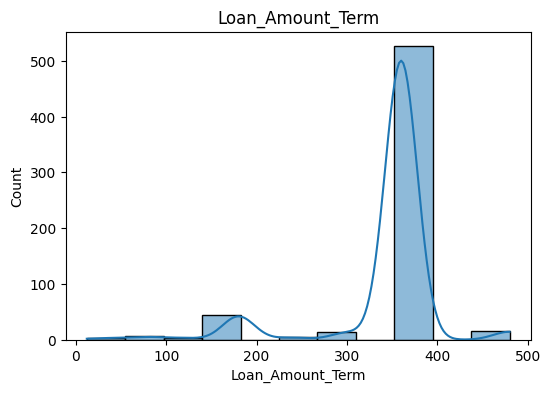

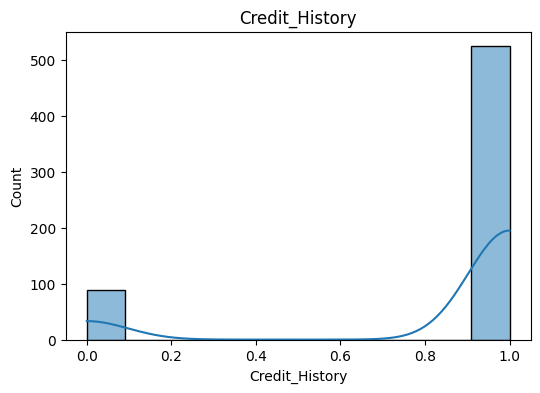

In [325]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

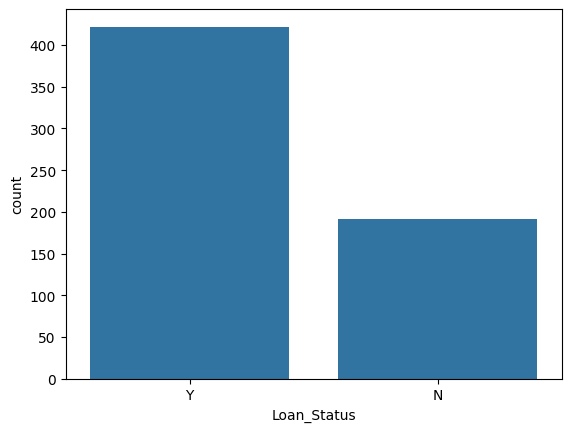

Loan_Status
Y    422
N    192
Name: count, dtype: int64
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


In [326]:
# Target variable distribution

sns.countplot( x = 'Loan_Status', data = df )
plt.show()

print( df['Loan_Status'].value_counts())
print( df['Loan_Status'].value_counts( normalize = True ) * 100)

In [327]:
print( 'categorical columns:', categorical_cols)

categorical columns: Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')


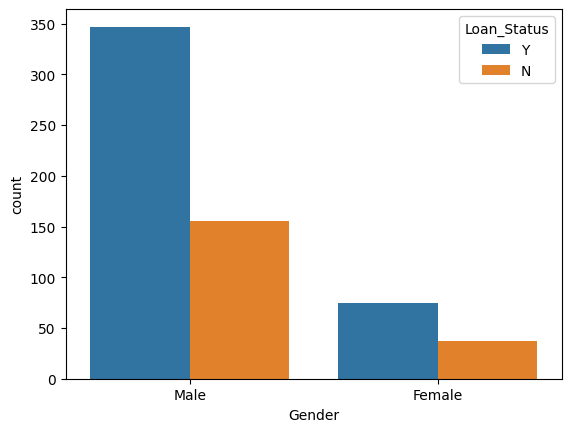

In [328]:
# Bivariate Analysis

sns.countplot( x = 'Gender', hue = 'Loan_Status', data = df )
plt.show()

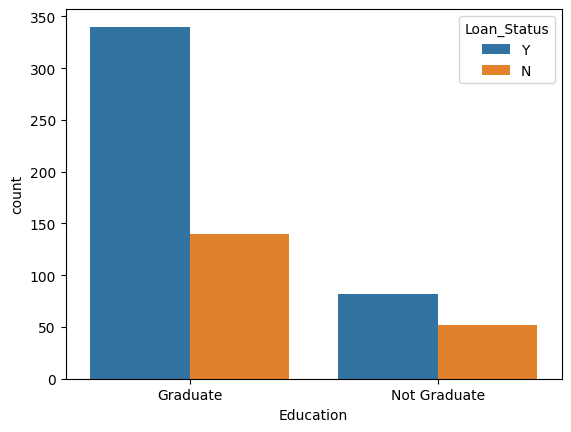

In [329]:
sns.countplot( x = 'Education', hue = 'Loan_Status', data = df )
plt.show()

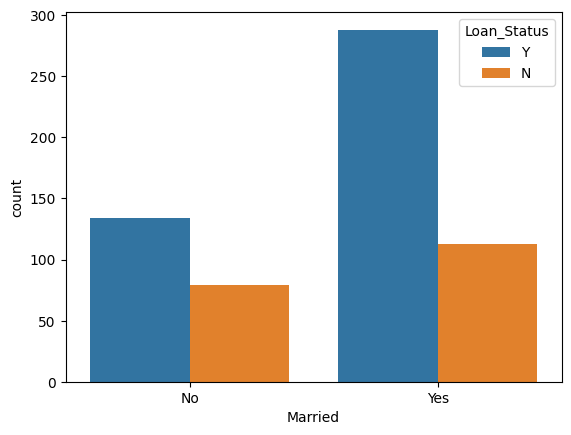

In [330]:
sns.countplot( x = 'Married', hue = 'Loan_Status', data = df )
plt.show()

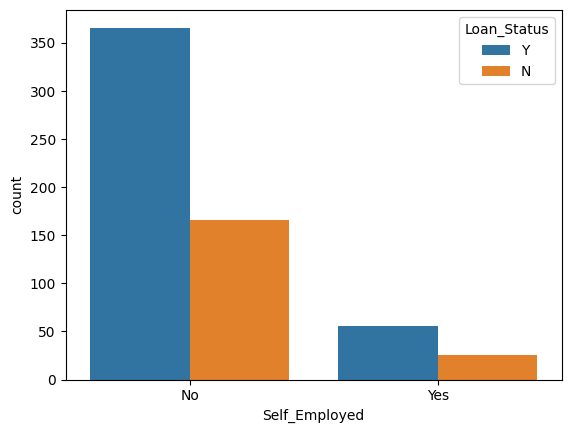

In [331]:
sns.countplot( x = 'Self_Employed', hue = 'Loan_Status', data = df )
plt.show()

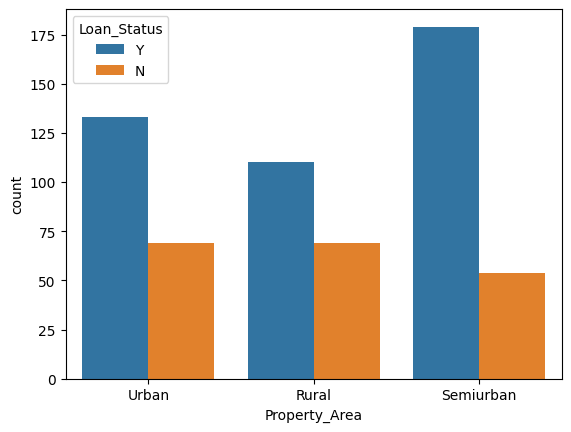

In [332]:
sns.countplot( x = 'Property_Area', hue = 'Loan_Status', data = df )
plt.show()

# Bivariate Analysis – Key Observations
Married applicants appear to have a higher loan approval rate than unmarried applicants.
Graduates have a higher proportion of loan approvals compared to non-graduates.
Applicants from Semiurban areas show a higher loan approval rate than those from Urban and Rural areas.
Self-employed applicants appear to have a lower loan approval rate compared to applicants who are not self-employed.

In [333]:
print( 'Numerical columns:', numerical_cols)

Numerical columns: Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')


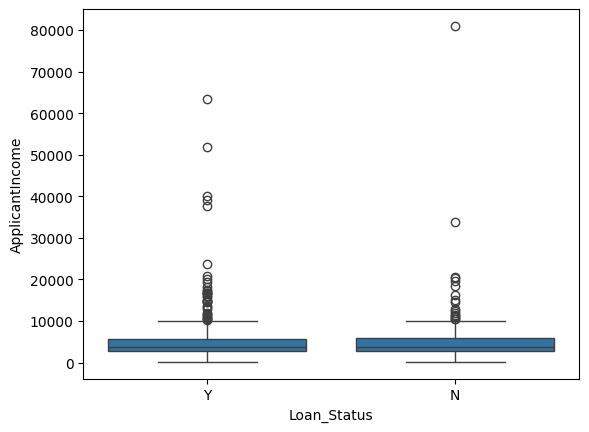

Loan_Status
N    3833.5
Y    3812.5
Name: ApplicantIncome, dtype: float64


In [334]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.show()
print(df.groupby('Loan_Status')['ApplicantIncome'].median())

In [335]:
# Correlation Matrix

corr = df.select_dtypes( include = ['int64', 'float']).corr()

<Axes: >

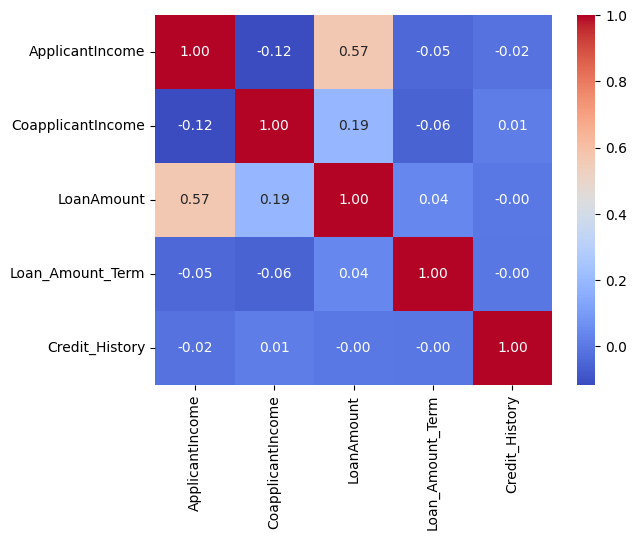

In [336]:
sns.heatmap( corr, annot = True, cmap = 'coolwarm', fmt = '.2f')

 The absence of highly correlated features indicates that multicollinearity is not a significant concern in this dataset. Therefore, it is unnecessary to remove features based solely on correlation. All numerical features can be retained for model training, allowing machine learning algorithms to identify complex relationships between the predictors and the target variable.

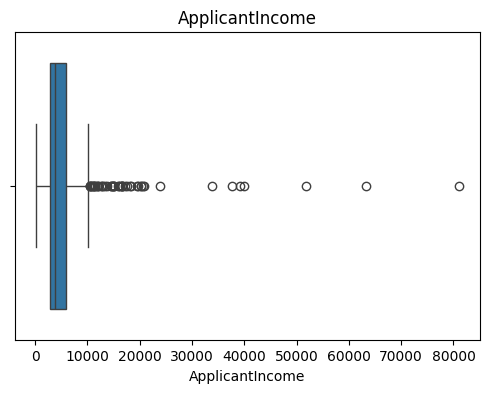

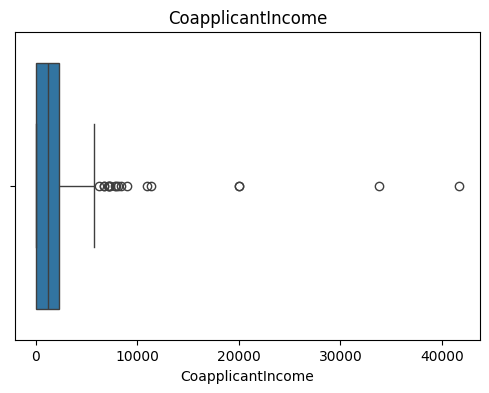

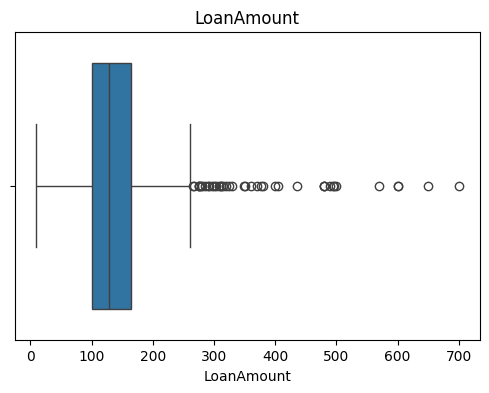

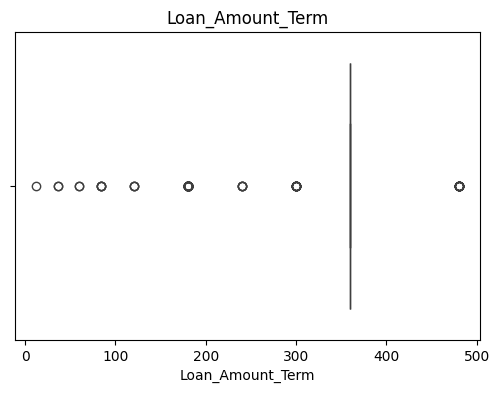

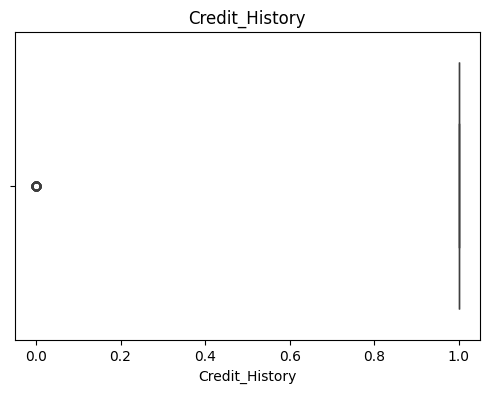

In [337]:
# Outlier detection

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [338]:
print( 'Numerical columns:', numerical_cols)

Numerical columns: Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')


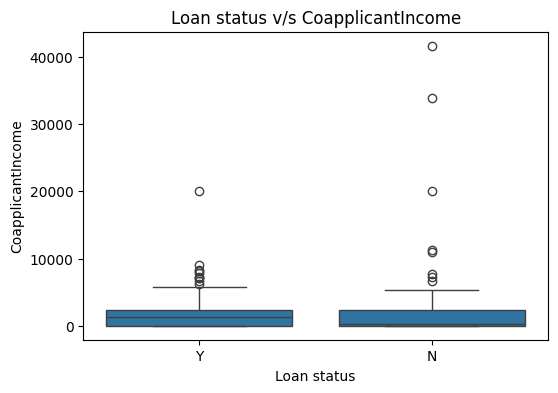

In [339]:
plt.figure(figsize = (6,4))

sns.boxplot( data = df, x = 'Loan_Status', y = 'CoapplicantIncome')

plt.title("Loan status v/s CoapplicantIncome")
plt.xlabel("Loan status")
plt.ylabel("CoapplicantIncome")
plt.show()

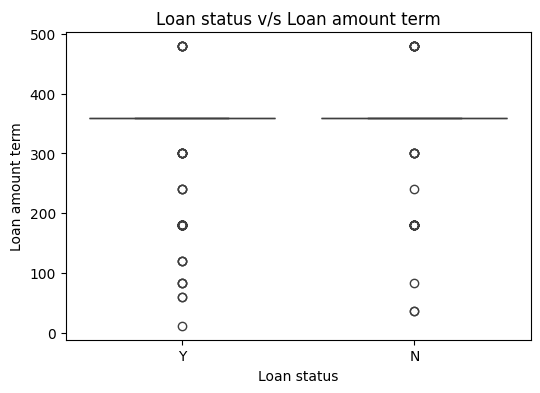

In [340]:
plt.figure(figsize = (6,4))

sns.boxplot( data = df, x = 'Loan_Status', y = 'Loan_Amount_Term')

plt.title("Loan status v/s Loan amount term")
plt.xlabel("Loan status")
plt.ylabel("Loan amount term")
plt.show()

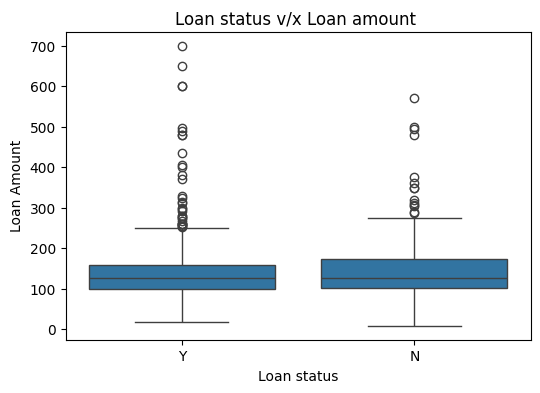

In [341]:
plt.figure(figsize = (6,4))

sns.boxplot( data = df, x = 'Loan_Status', y = 'LoanAmount')

plt.title("Loan status v/x Loan amount ")
plt.xlabel("Loan status")
plt.ylabel("Loan Amount")
plt.show()

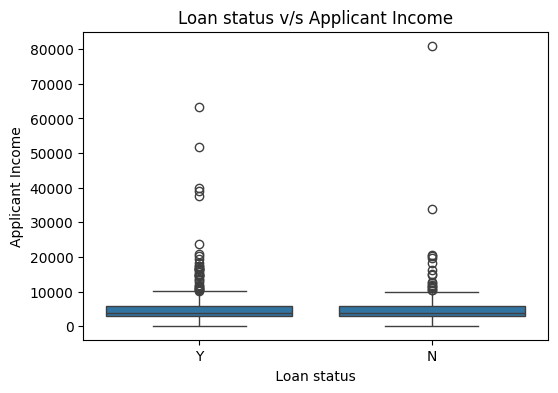

In [342]:
plt.figure(figsize = (6,4))

sns.boxplot(data = df, x = 'Loan_Status', y = 'ApplicantIncome')

plt.title("Loan status v/s Applicant Income")
plt.xlabel(" Loan status ")
plt.ylabel("Applicant Income")

plt.show()

The outliers in ApplicantIncome were retained because they appear to be genuine observations. The visualization shows that several applicants with exceptionally high incomes received loan approval, suggesting these values are valid business records and should not be removed from the analysis.

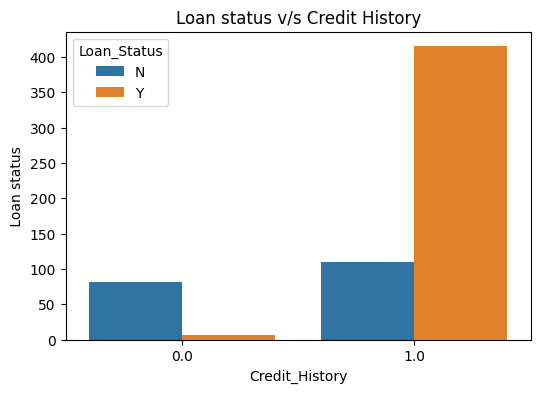

In [343]:
plt.figure(figsize = (6,4))

sns.countplot(data=df, x='Credit_History', hue='Loan_Status')

plt.title("Loan status v/s Credit History")
plt.ylabel(" Loan status ")
plt.xlabel("Credit_History")

plt.show()

Although the box plots detect several outliers, they are likely to be genuine because they represent valid and realistic loan-related values rather than data errors. Hence, these outliers are retained in the dataset instead of being removed.

# Feature Engineering

In [344]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [345]:
# Drop unnecessary columns

df = df.drop('Loan_ID', axis  = 1)

In [346]:
# Encode categorical variables
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)
print( 'categorical columns:', categorical_cols)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')
categorical columns: Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')


In [347]:
# One-Hot Encoding for Nominal Columns

nominal_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

df = pd.get_dummies( df, columns = nominal_cols, drop_first = True)

In [348]:
# Original Encoding for Depenents columns

df['Dependents'] = df['Dependents'].replace({'3+': 3})
df['Dependents'] = df['Dependents'].astype(int)
                                             

In [349]:
# Separate features and target

x = df.drop('Loan_Status', axis = 1)
y = df['Loan_Status']


In [350]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,128.0,360.0,1.0,Y,True,False,False,False,False,True
1,1,4583,1508.0,128.0,360.0,1.0,N,True,True,False,False,False,False
2,0,3000,0.0,66.0,360.0,1.0,Y,True,True,False,True,False,True
3,0,2583,2358.0,120.0,360.0,1.0,Y,True,True,True,False,False,True
4,0,6000,0.0,141.0,360.0,1.0,Y,True,False,False,False,False,True


One-Hot Encoding was applied to the nominal categorical features (Gender, Married, Education, Self_Employed, and Property_Area) because these variables do not have a natural order. Ordinal Encoding was applied to the Dependents feature since it has a meaningful order (0 < 1 < 2 < 3+), preserving the ordinal relationship among the categories.

In [351]:
y = y.map({'Y': 1, 'N': 0})

In [352]:
# Train-test split

from sklearn.model_selection import train_test_split

x_train , x_test, y_train, y_test = train_test_split( x,y, test_size = 0.20, random_state = 42, stratify  =y)

In [353]:
# Create multiple classifiers

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [357]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier( random_state  = 42),
    'RandomForest' : RandomForestClassifier( random_state = 42 ),
    'AdaBoost': AdaBoostClassifier( random_state = 42),
    'Gradient Boosting' : GradientBoostingClassifier( random_state = 42 ),
    'Naive bayes' : GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC( probability = True, random_state = 42 )

}

In [358]:
from sklearn.metrics import accuracy_score, precision_score, recall_score 

In [359]:
# Train and Evaluate All Models

results = []

for name, model in models.items():

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    results.append({
        'Models': name,
        'Accuracy score' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    })

results_df = pd.DataFrame( results)
results_df.sort_values( by = 'Accuracy score', ascending = False)

print( results_df)
    

C:\Users\mohan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                Models  Accuracy score  Precision    Recall
0  Logistic Regression        0.861789   0.840000  0.988235
1        Decision Tree        0.723577   0.800000  0.800000
2         RandomForest        0.837398   0.857143  0.917647
3             AdaBoost        0.853659   0.838384  0.976471
4    Gradient Boosting        0.821138   0.824742  0.941176
5          Naive bayes        0.845528   0.836735  0.964706
6                  KNN        0.650407   0.718750  0.811765
7                  SVM        0.691057   0.691057  1.000000


In [361]:
# Feature scaling for distance based algorithms

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_Scaled = scaler.transform(x_test)

In [362]:
modelss = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC( probability = True, random_state = 42 )

}

In [364]:
# Train and Evaluate All Models

results = []

for name, model in modelss.items():

    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_Scaled)

    results.append({
        'Models': name,
        'Accuracy score' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    })

results_df = pd.DataFrame( results)
results_df.sort_values( by = 'Accuracy score', ascending = False)

print( results_df)

                Models  Accuracy score  Precision    Recall
0  Logistic Regression        0.861789   0.840000  0.988235
1                  KNN        0.837398   0.828283  0.964706
2                  SVM        0.853659   0.831683  0.988235


Feature scaling using StandardScaler was applied before training KNN and SVM because these algorithms are distance-based. After scaling, KNN accuracy improved from 65.04% to 83.74%, while SVM accuracy improved from 69.11% to 85.37%. This confirms that feature scaling significantly enhances the performance of distance-based classifiers.

# Model Selection: 

Based on the baseline evaluation, the top four models were selected for hyperparameter tuning:

Logistic Regression – Highest accuracy (86.18%) with excellent recall (98.82%).
AdaBoost – Second-highest accuracy (85.37%) and strong overall performance.
Support Vector Machine (SVM) – After feature scaling, achieved 85.37% accuracy with excellent recall (98.82%).
Random Forest – Achieved 83.74% accuracy with the highest precision (85.71%) among the evaluated models.

These models were chosen because they demonstrated the best balance of accuracy, precision, and recall compared with the other classifiers. Hyperparameter tuning will be performed to further optimize their performance.

# Hyper parameter tuning

In [383]:
from sklearn.model_selection import RandomizedSearchCV

In [384]:
# Logistic Regression Parameters

logistic_params = {
    'classifier': [LogisticRegression(max_iter=1000)],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs']
}

# Random Forest Parameters
rf_params = {

    'classifier': [RandomForestClassifier(random_state=42)],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# AdaBoost Parameters
ada_params = {

    'classifier': [AdaBoostClassifier(random_state=42)],
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 1]
}

# SVM Parameters
svm_params = {
    'classifier': [SVC()],
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

In [385]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('classifier', LogisticRegression())   # Placeholder classifier
])

In [386]:
param_distributions = [
    logistic_params,
    rf_params,
    ada_params,
    svm_params
]

In [387]:
random_search = RandomizedSearchCV(
    estimator = pipeline,
    param_distributions = param_distributions,
    n_iter = 20,
    cv  =5,
    scoring  = 'accuracy',
    random_state  =42,
    n_jobs = -1
)
    
  

In [388]:
random_search.fit(x_train_scaled, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('classifier',
                                              LogisticRegression())]),
                   n_iter=20, n_jobs=-1,
                   param_distributions=[{'classifier': [LogisticRegression(max_iter=1000)],
                                         'classifier__C': [0.01, 0.1, 1, 10,
                                                           100],
                                         'classifier__solver': ['liblinear',
                                                                'lbfgs']},
                                        {'classifier': [RandomForestClassifier(random_state=42)],
                                         'classifier__max_depth': [None, 10,
                                                                   20...
                                         'classifier__min_samples_split': [2, 5,
                                                                           10],
                                         'classifier__n_estimators': [100, 200,
                                                                      300]},
                                        {'classifier': [AdaBoostClassifier(random_state=42)],
                                         'classifier__learning_rate': [0.01,
                                                                       0.1, 1],
                                         'classifier__n_estimators': [50, 100,
                                                                      200]},
                                        {'classifier': [SVC()],
                                         'classifier__C': [0.1, 1, 10],
                                         'classifier__gamma': ['scale', 'auto'],
                                         'classifier__kernel': ['linear',
                                                                'rbf']}],
                   random_state=42, scoring='accuracy')

In [389]:
print("Best Model:", random_search.best_estimator_)
print("Best Parameters:", random_search.best_params_)
print("Best Cross Validation Score:", random_search.best_score_)

Best Model: Pipeline(steps=[('classifier',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=4,
                                        random_state=42))])
Best Parameters: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 10, 'classifier': RandomForestClassifier(random_state=42)}
Best Cross Validation Score: 0.8004122861265719


# Observation:

RandomizedSearchCV was applied to four selected classifiers: Logistic Regression, Random Forest, AdaBoost, and SVM. Based on 5-fold cross-validation, Random Forest was selected as the best-performing model. The optimal hyperparameters were 100 estimators, maximum depth of 10, minimum samples split of 2, and minimum samples leaf of 4. These parameters help improve the model's ability to generalize while reducing the risk of overfitting.

In [390]:
# Evaluate the Tuned Model

best_model  =random_search.best_estimator_

y_pred_tuned = best_model.predict(x_test_Scaled)

In [393]:
from sklearn.metrics import confusion_matrix, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report")
print(classification_report(y_test, y_pred_tuned))

Accuracy : 0.8536585365853658
Precision: 0.8383838383838383
Recall   : 0.9764705882352941

Confusion Matrix
[[22 16]
 [ 2 83]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.58      0.71        38
           1       0.84      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.88      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



In [422]:
# RandomizedSearchCV selected Random Forest as the best model.
# However, to get a fair comparison, I wanted to test each model separately because RandomizedSearchCV only tries random hyperparameter combinations and selects the model based on the cross-validation score.
# Therefore, each shortlisted model was tuned individually to compare their performance fairly.

In [395]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('classifier', LogisticRegression(max_iter=1000))
])

logistic_params = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs']
}

lr_random = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=logistic_params,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

lr_random.fit(x_train_scaled, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('classifier',
                                              LogisticRegression(max_iter=1000))]),
                   n_jobs=-1,
                   param_distributions={'classifier__C': [0.01, 0.1, 1, 10,
                                                          100],
                                        'classifier__solver': ['liblinear',
                                                               'lbfgs']},
                   random_state=42, scoring='accuracy')

In [408]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=rf_params,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__max_depth': [None, 10, 20],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   random_state=42, scoring='accuracy')

In [409]:
from sklearn.ensemble import AdaBoostClassifier

pipeline = Pipeline([
    ('classifier', AdaBoostClassifier(random_state=42))
])

ada_params = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 1]
}

ada_random = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=ada_params,
    n_iter=9,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

ada_random.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('classifier',
                                              AdaBoostClassifier(random_state=42))]),
                   n_iter=9, n_jobs=-1,
                   param_distributions={'classifier__learning_rate': [0.01, 0.1,
                                                                      1],
                                        'classifier__n_estimators': [50, 100,
                                                                     200]},
                   random_state=42, scoring='accuracy')

In [399]:
from sklearn.svm import SVC

pipeline = Pipeline([
    ('classifier', SVC())
])

svm_params = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

svm_random = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=svm_params,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

svm_random.fit(x_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=Pipeline(steps=[('classifier', SVC())]),
                   n_jobs=-1,
                   param_distributions={'classifier__C': [0.1, 1, 10],
                                        'classifier__gamma': ['scale', 'auto'],
                                        'classifier__kernel': ['linear',
                                                               'rbf']},
                   random_state=42, scoring='accuracy')

In [401]:
best_lr = lr_random.best_estimator_

y_pred1 = best_lr.predict(x_test_Scaled)

print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))
print("Recall:", recall_score(y_test, y_pred1))

Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471


In [410]:
best_rf = rf_random.best_estimator_

y_pred2 = best_rf.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall   :", recall_score(y_test, y_pred2))

Accuracy : 0.8455284552845529
Precision: 0.8367346938775511
Recall   : 0.9647058823529412


In [411]:
best_ada = ada_random.best_estimator_

y_pred3 = best_ada.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3))
print("Recall   :", recall_score(y_test, y_pred3))


Accuracy : 0.8536585365853658
Precision: 0.8316831683168316
Recall   : 0.9882352941176471


In [407]:
best_svm = svm_random.best_estimator_

y_pred4 = best_svm.predict(x_test_Scaled)

print("Accuracy :", accuracy_score(y_test, y_pred4))
print("Precision:", precision_score(y_test, y_pred4))
print("Recall   :", recall_score(y_test, y_pred4))

Accuracy : 0.8536585365853658
Precision: 0.8316831683168316
Recall   : 0.9882352941176471


In [413]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'AdaBoost', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, best_lr.predict(x_test_Scaled)),
        accuracy_score(y_test, best_rf.predict(x_test)),
        accuracy_score(y_test, best_ada.predict(x_test)),
        accuracy_score(y_test, best_svm.predict(x_test_Scaled))
    ],
    'Precision': [
        precision_score(y_test, best_lr.predict(x_test_Scaled)),
        precision_score(y_test, best_rf.predict(x_test)),
        precision_score(y_test, best_ada.predict(x_test)),
        precision_score(y_test, best_svm.predict(x_test_Scaled))
    ],
    'Recall': [
        recall_score(y_test, best_lr.predict(x_test_Scaled)),
        recall_score(y_test, best_rf.predict(x_test)),
        recall_score(y_test, best_ada.predict(x_test)),
        recall_score(y_test, best_svm.predict(x_test_Scaled))
    ]
})

comparison.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.861789,0.840000,0.988235
2,AdaBoost,0.853659,0.831683,0.988235
3,SVM,0.853659,0.831683,0.988235
1,Random Forest,0.845528,0.836735,0.964706


After comparing the tuned classification models, Logistic Regression was selected as the final model because it achieved the highest accuracy of 86.18% along with a high precision of 84.00% and an excellent recall of 98.82%. Therefore, Logistic Regression provides the best overall performance for predicting loan approval on this dataset.

# Observation

Initially, RandomizedSearchCV was applied to all selected classifiers together to identify a promising model. However, to ensure a fair and reliable comparison, each shortlisted model (Logistic Regression, Random Forest, AdaBoost, and SVM) was tuned individually using RandomizedSearchCV. Tuning the models separately allowed each algorithm to be optimized using its own set of hyperparameters without being influenced by the search space of other models. This approach provided a more accurate evaluation of each model's performance on the dataset. After comparing the tuned models using accuracy, precision, recall, and ROC-AUC, Logistic Regression achieved the best overall performance and was selected as the final model for loan approval prediction.

ROC-AUC Score: 0.848297213622291


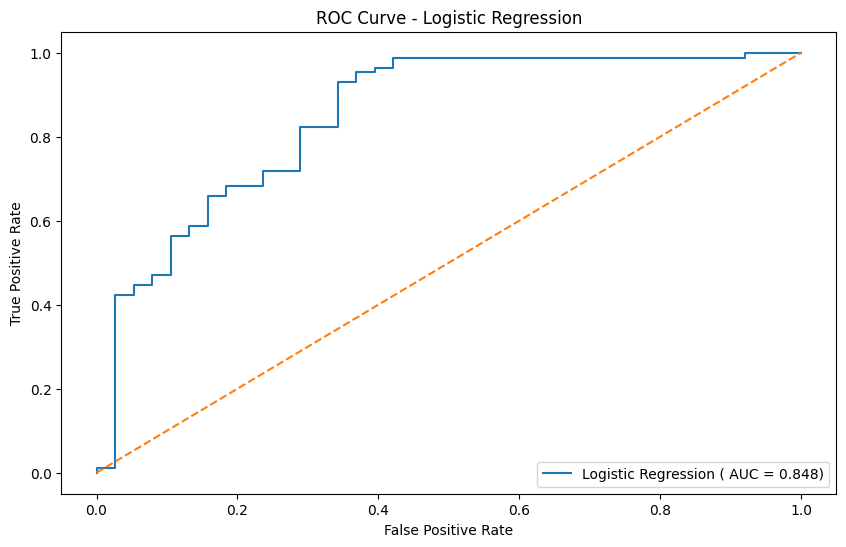

In [415]:
# ROC Curve and ROC-AUC

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities
y_prob = best_lr.predict_proba( x_test_Scaled)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

# Plot ROC Curve

plt.figure(figsize=  (10,6))
plt.plot(fpr, tpr, label = f'Logistic Regression ( AUC = { auc_score :.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc='lower right')
plt.show()



The ROC curve was plotted to evaluate the classification performance of the final Logistic Regression model. The model achieved an ROC-AUC score of 0.8483, indicating good discriminative ability between approved and rejected loan applications. Since the ROC curve lies well above the diagonal reference line, the model performs considerably better than random classification and demonstrates strong predictive capability.

In [416]:
# Predict a single unseen loan application

new_data = pd.DataFrame({
    'Dependents': [1],
    'ApplicantIncome': [5000],
    'CoapplicantIncome': [1500],
    'LoanAmount': [120],
    'Loan_Amount_Term': [360],
    'Credit_History': [1],
    'Gender_Male': [1],
    'Married_Yes': [1],
    'Education_Not Graduate': [0],
    'Self_Employed_Yes': [0],
    'Property_Area_Semiurban': [1],
    'Property_Area_Urban': [0]
})

In [417]:
new_data_scaled = scaler.transform(new_data)

In [418]:
prediction = best_lr.predict(new_data_scaled)

if prediction[0] == 'Y':
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Rejected


In [419]:
probability = best_lr.predict_proba(new_data_scaled)

print("Probability:", probability)

Probability: [[0.142566 0.857434]]


The trained Logistic Regression model was tested on an unseen loan application. The model predicted that the loan would be approved (Y) with a probability of 85.74%, while the probability of rejection was 14.26%. This indicates that the applicant has a high likelihood of receiving loan approval based on the learned patterns from the training data.

In [420]:
prediction = best_lr.predict(new_data_scaled)
probability = best_lr.predict_proba(new_data_scaled)

print("Predicted Loan Status:", prediction[0])
print(f"Probability of Rejection (N): {probability[0][0]*100:.2f}%")
print(f"Probability of Approval (Y): {probability[0][1]*100:.2f}%")

Predicted Loan Status: 1
Probability of Rejection (N): 14.26%
Probability of Approval (Y): 85.74%


# Project Conclusion

In this project, a Loan Approval Prediction model was developed using machine learning classification algorithms. The dataset was first explored through Exploratory Data Analysis (EDA) to understand the distribution of features, identify missing values, detect outliers, and analyze relationships between variables. Missing values were handled appropriately, categorical features were encoded using suitable encoding techniques, and feature scaling was applied where required.

Multiple classification algorithms, including Logistic Regression, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, Naive Bayes, KNN, and SVM, were trained and evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix. Based on the initial results, the top-performing models were shortlisted for hyperparameter tuning.

Hyperparameter tuning was initially performed using RandomizedSearchCV. To ensure a fair comparison, each shortlisted model was then tuned individually, allowing every algorithm to be optimized with its own hyperparameter search space. The tuned models were compared based on their evaluation metrics.

Among all the tuned models, Logistic Regression achieved the best overall performance with an Accuracy of 86.18%, Precision of 84.00%, Recall of 98.82%, and an ROC-AUC score of 0.8483. The high recall indicates that the model correctly identifies the majority of approved loan applications, while the ROC-AUC score demonstrates good discrimination between approved and rejected loans.

Finally, the selected Logistic Regression model was tested on unseen loan application data. The model successfully predicted the loan approval status and provided the probability of approval, demonstrating its ability to generalize to new data.

Overall, the developed Loan Approval Prediction model is capable of assisting financial institutions in making consistent, data-driven loan approval decisions. The project demonstrates the complete machine learning workflow, including data preprocessing, exploratory data analysis, feature engineering, model building, hyperparameter tuning, model evaluation, and prediction on unseen data.